# run_analysis - interactive notebook version

Use as a working template with each step kept as inspectable variables. 

Converted from `run_analysis.py` (same code with `#%%` cell boundaries) for testing/iteration.

Flow:
1. Load & subset data (with day/phase/time_point/sex/age filters)
2. Aggregate to mouse-level (session means, or day-level, or whatever grouping)
3. Compute domain scores
4. Box-paired ELA vs CTRL comparison (baseline)
5. Explore by day
6. Explore by time window 
7. Treatment effect x background (mixed model)
8. add more analyses here as you go


## 0. Import packages and modules

In [1]:
import sys
sys.path.insert(0, 'lib')
import pandas as pd
import os

from prep import load_data, filter_data
from aggregate import aggregate_to_mouse, box_paired_wide, mouse_level_deltas, box_level_means
from domain_scores import compute_domain_scores, CORE_DOMAINS, ALL_DOMAINS, CORE_DOMAIN_FEATURES, ALL_DOMAIN_FEATURES 
from stats_utils import paired_effect_table, box_level_delta_table


MOUSE_ID_COLS = ['mouse_ID', 'sex', 'age', 'background', 'treatment', 'box_ID']


## 1. Load & subset data

In [2]:
# use filtered csv files, 12h resolution
DATA_PATH = '/Users/xiuqi.ji/Library/CloudStorage/OneDrive-KarolinskaInstitutet/MDMA_ELA/social_box_2026/github_repo/behavior_dataset/final/QC_table'
FEMALE_12H_PATH = '/Users/xiuqi.ji/Library/CloudStorage/OneDrive-KarolinskaInstitutet/MDMA_ELA/social_box_2026/github_repo/behavior_dataset/final/QC_table/female_12h_filtered.csv'
MALE_12H_PATH = '/Users/xiuqi.ji/Library/CloudStorage/OneDrive-KarolinskaInstitutet/MDMA_ELA/social_box_2026/github_repo/behavior_dataset/final/QC_table/male_12h_filtered.csv'

df = load_data(female_path=FEMALE_12H_PATH, male_path=MALE_12H_PATH)

# Baseline, active phase, all 3 days (the default subset):
baseline_active = filter_data(df, phase='active', time_point='baseline')

[drop_known_bad_blocks] dropping 32 rows: male P35 day1 active MDMA session: hours 0-5 of active phase not recorded (confirmed via 1h-resolution file - rows are entirely absent, not NaN). See matched_window_recovery.py for how to recover a partial-window comparison instead of dropping outright.


In [5]:
# To restrict to specific days instead, e.g. day 1 only:
baseline_active_day1 = filter_data(df, phase='active', time_point='baseline', days=[1])
# Or day 2 and 3 only:
baseline_active_day23 = filter_data(df, phase='active', time_point='baseline', days=[2, 3])

## 2. Aggregate to mouse-level

This step computes "session means": collapse the repeated measures within the defined session into a single baseline value per mouse.

The session can also be altered with `group_cols` (currently `MOUSE_ID_COLS` -> `['mouse_ID', 'sex', 'age', 'background', 'treatment', 'box_ID']`), use either whole session, day, or time_window as the unit.

This is the standard denominator for domain-score z-scoring (see step 3) and for the box-paired comparison in step 4.

In [ ]:
RAW_FEATURES_FOR_DOMAINS = sorted({f for spec in ALL_DOMAINS.values()
                                    for f in spec['features'] + spec.get('flip', [])})

In [ ]:
mouse_baseline = aggregate_to_mouse(baseline_active, MOUSE_ID_COLS, RAW_FEATURES_FOR_DOMAINS)

In [7]:
mouse_baseline_day1 = aggregate_to_mouse(baseline_active_day1, MOUSE_ID_COLS, RAW_FEATURES_FOR_DOMAINS)
mouse_baseline_day23 = aggregate_to_mouse(baseline_active_day23, MOUSE_ID_COLS, RAW_FEATURES_FOR_DOMAINS)

## 3. Compute domain scores

compute_domain_scores adds z-scored composite column for the domains in `domain_defs` (`CORE_DOMAINS` by default) to a copy of the df. 

Z-scoring is done separately for male/female using the mean/SD (or median/MAD if skewed) of the `reference_mask` rows as the reference distribution (default = `None` -> all rows are used). When the df has both baseline and post-treatment rows, pass `reference_mask=(df['time_point']=='baseline')` to keep baseline and MDMA-session values on the same scale.

In [8]:
# reference_mask=None here because mouse_baseline is ALREADY baseline-only
# Use domain_defs=ALL_DOMAINS instead to include the supplementary finer-grained splits.

mouse_baseline = compute_domain_scores(mouse_baseline, domain_defs=ALL_DOMAINS)
mouse_baseline_day1 = compute_domain_scores(mouse_baseline_day1, domain_defs=ALL_DOMAINS)
mouse_baseline_day23 = compute_domain_scores(mouse_baseline_day23, domain_defs=ALL_DOMAINS)

## 4. Baseline: ELA vs CTRL comparison 

In [4]:
# define names
savepath = "/Users/xiuqi.ji/Library/CloudStorage/OneDrive-KarolinskaInstitutet/MDMA_ELA/social_box_2026/plots/baseline_ELA_vs_CTRL"

### 4.0. calculate box-paired effects

box_paired_wide averages the 2 ELA and 2 CTRL mice within each box separately, and produces a wide table with one row per box per `extra_group_cols`.

paired_effect_table makes paired (by box) comparison of feature_ELA vs feature_CTRL and returns *mean_diff*, *cohen_dz* (paired effect size), *t*, *p*, *p_wilcoxon*, *p_fdr*.

**tested different subsets: all 3 days average, day1, day2/3 average**

In [10]:
suffix ='3days'
wide = box_paired_wide(mouse_baseline, features=CORE_DOMAIN_FEATURES)

In [ ]:
suffix ='day1'
wide = box_paired_wide(mouse_baseline_day1, features=CORE_DOMAIN_FEATURES)

In [ ]:
suffix ='day23'
wide = box_paired_wide(mouse_baseline_day23, features=CORE_DOMAIN_FEATURES)

In [11]:
# print the comparison table with p values, uncomment to_csv line to save
print("=" * 70)
print("BASELINE: ELA vs CTRL, domain scores (box-paired)")
print("=" * 70)
baseline_effect_tables = {}
for sex in ['female', 'male']:
    sub = wide[wide.sex == sex]
    res = paired_effect_table(sub, CORE_DOMAIN_FEATURES)
    #res.to_csv(os.path.join(savepath, f'baseline_effect_table_{suffix}_{sex}_core.csv'),index=False)
    baseline_effect_tables[sex] = res
    print(f"\n--- {sex} (n={len(sub)} box pairs) ---")
    print(res[['feature', 'cohen_dz', 'p_ttest', 'p_fdr']].to_string(index=False))

BASELINE: ELA vs CTRL, domain scores (box-paired)

--- female (n=16 box pairs) ---
                            feature  cohen_dz  p_ttest    p_fdr
                   locomotion_score -0.755928 0.008550 0.102595
               nest_occupancy_score  0.595937 0.030787 0.166551
  social_affiliation_activity_score  0.556905 0.041638 0.166551
             social_hierarchy_score -0.485184 0.071323 0.213968
           nest_fragmentation_score -0.444369 0.095766 0.227091
      social_affiliation_nest_score -0.405250 0.125844 0.227091
resource_proximity_preference_score  0.397739 0.132470 0.227091
      feeding_drinking_amount_score -0.371294 0.158209 0.237313
          movement_complexity_score  0.347441 0.184884 0.246512
                     speeding_score  0.317370 0.223614 0.268336
                  exploration_score -0.274511 0.289500 0.315818
                   inactivity_score  0.099102 0.697385 0.697385

--- male (n=16 box pairs) ---
                            feature  cohen_dz      p_t

### 4.1 Plot paired effect results

Forest plot of the table above (see `plot_effect_table.py` for the function signature).

Pass `save_path=None` (default) to just display; set it to write a PNG instead/as well.

In [12]:
from plot_effect_table import plot_effect_table

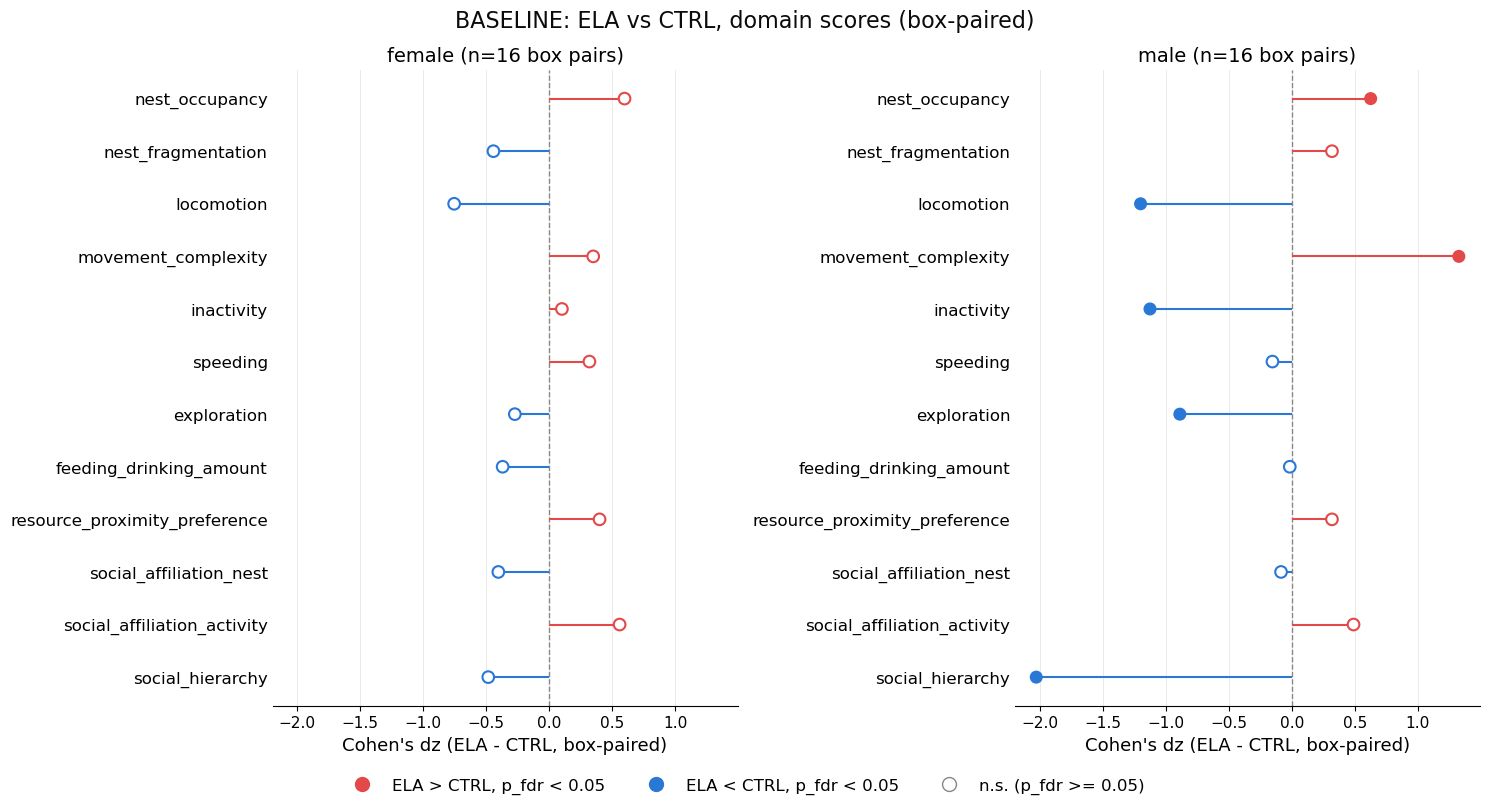

(<Figure size 1500x800 with 2 Axes>,
 array([<Axes: title={'center': 'female (n=16 box pairs)'}, xlabel="Cohen's dz (ELA - CTRL, box-paired)">,
        <Axes: title={'center': 'male (n=16 box pairs)'}, xlabel="Cohen's dz (ELA - CTRL, box-paired)">],
       dtype=object))

In [13]:

plot_effect_table(
    baseline_effect_tables,
    title='BASELINE: ELA vs CTRL, domain scores (box-paired)',
    save_path=None,
)
#os.path.join(savepath,f'baseline_effect_all_features_{suffix}.png')

### 4.2 Plot baseline ELA vs CTRL details
See `plot_by_box.py` for function specifics.

Visualize box-level ELA vs CTRL comparisons of the domain scores.

The line connects paired ELA and CTRL values.

In [14]:
from plot_by_box import plot_domains_by_box_grid, top_panels_by_effect, plot_all_domains_grid

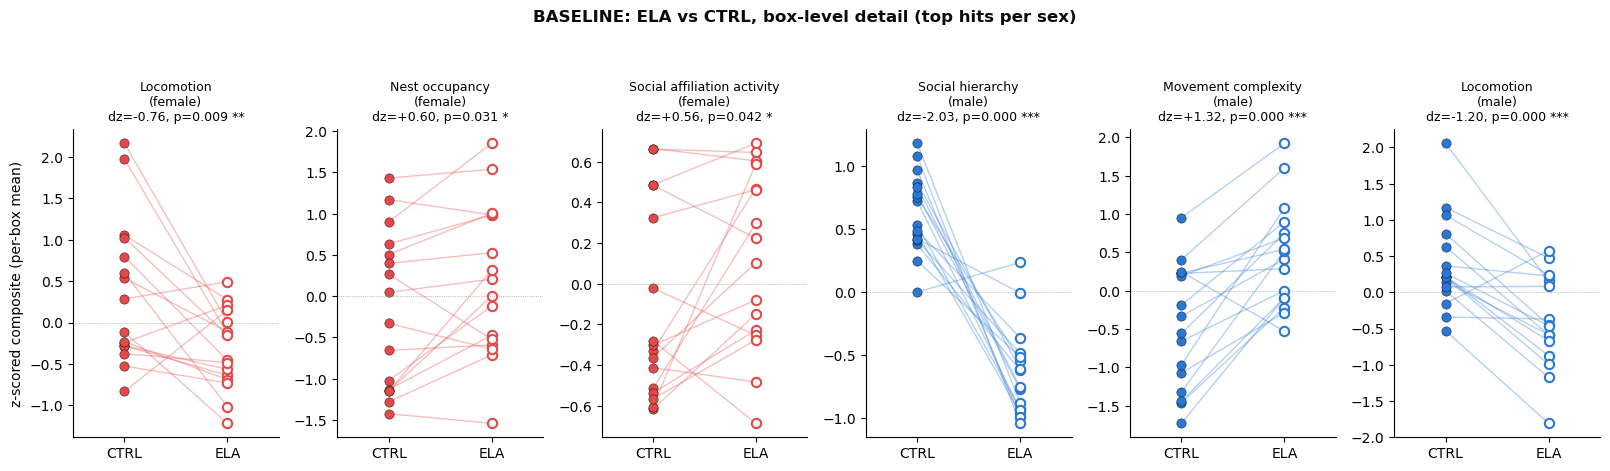

(<Figure size 1620x440 with 6 Axes>,
 array([<Axes: title={'center': 'Locomotion\n(female)\ndz=-0.76, p=0.009 **'}, ylabel='z-scored composite (per-box mean)'>,
        <Axes: title={'center': 'Nest occupancy\n(female)\ndz=+0.60, p=0.031 *'}>,
        <Axes: title={'center': 'Social affiliation activity\n(female)\ndz=+0.56, p=0.042 *'}>,
        <Axes: title={'center': 'Social hierarchy\n(male)\ndz=-2.03, p=0.000 ***'}>,
        <Axes: title={'center': 'Movement complexity\n(male)\ndz=+1.32, p=0.000 ***'}>,
        <Axes: title={'center': 'Locomotion\n(male)\ndz=-1.20, p=0.000 ***'}>],
       dtype=object))

In [17]:
# Use baseline_panels to plot the top hits per sex 
baseline_panels = top_panels_by_effect(baseline_effect_tables, n_per_sex=3)
plot_domains_by_box_grid(
    wide, baseline_panels,
    title='BASELINE: ELA vs CTRL, box-level detail (top hits per sex)',
    save_path=os.path.join(savepath, f'baseline_box_detail_{suffix}_top3_hits.png'),
)


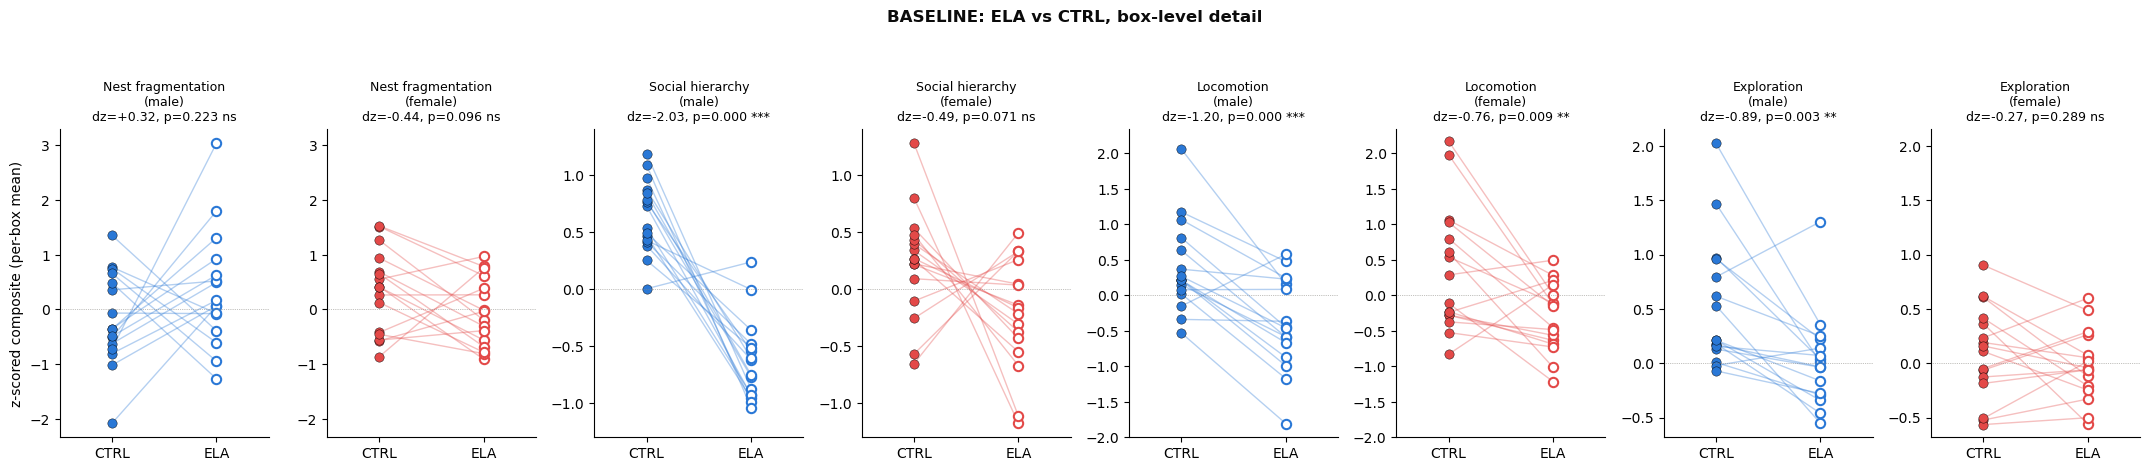

(<Figure size 2160x440 with 8 Axes>,
 array([<Axes: title={'center': 'Nest fragmentation\n(male)\ndz=+0.32, p=0.223 ns'}, ylabel='z-scored composite (per-box mean)'>,
        <Axes: title={'center': 'Nest fragmentation\n(female)\ndz=-0.44, p=0.096 ns'}>,
        <Axes: title={'center': 'Social hierarchy\n(male)\ndz=-2.03, p=0.000 ***'}>,
        <Axes: title={'center': 'Social hierarchy\n(female)\ndz=-0.49, p=0.071 ns'}>,
        <Axes: title={'center': 'Locomotion\n(male)\ndz=-1.20, p=0.000 ***'}>,
        <Axes: title={'center': 'Locomotion\n(female)\ndz=-0.76, p=0.009 **'}>,
        <Axes: title={'center': 'Exploration\n(male)\ndz=-0.89, p=0.003 **'}>,
        <Axes: title={'center': 'Exploration\n(female)\ndz=-0.27, p=0.289 ns'}>],
       dtype=object))

In [ ]:

# Use self-defined custom_panels to plot the domains of interest.
# set match_ylim_by_domain to True so that the scale is matched between sex 
custom_panels = [
    ('nest_fragmentation_score','male'),
    ('nest_fragmentation_score','female'),
    ('social_hierarchy_score', 'male'),
    ('social_hierarchy_score', 'female'),
    ('locomotion_score', 'male'),
    ('locomotion_score', 'female'),
    ('exploration_score', 'male'),
    ('exploration_score', 'female'),
]
plot_domains_by_box_grid(
    wide, custom_panels,
    title='BASELINE: ELA vs CTRL, box-level detail',
    match_ylim_by_domain=True,
    save_path=None,
)
#os.path.join(savepath, f'baseline_box_detail_{suffix}_selected_domain.png')

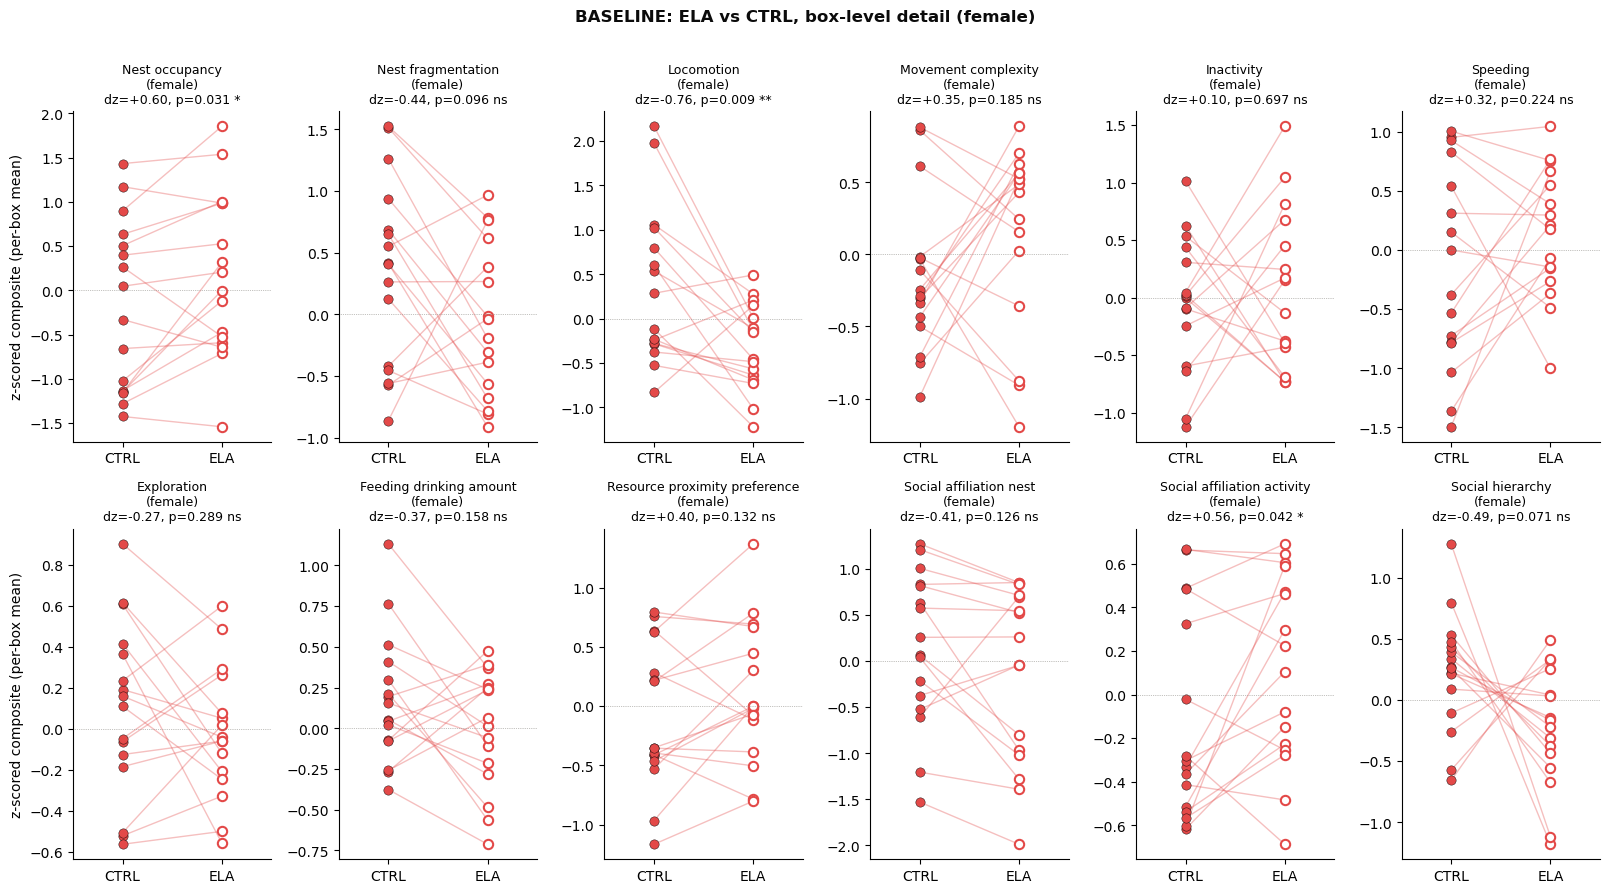

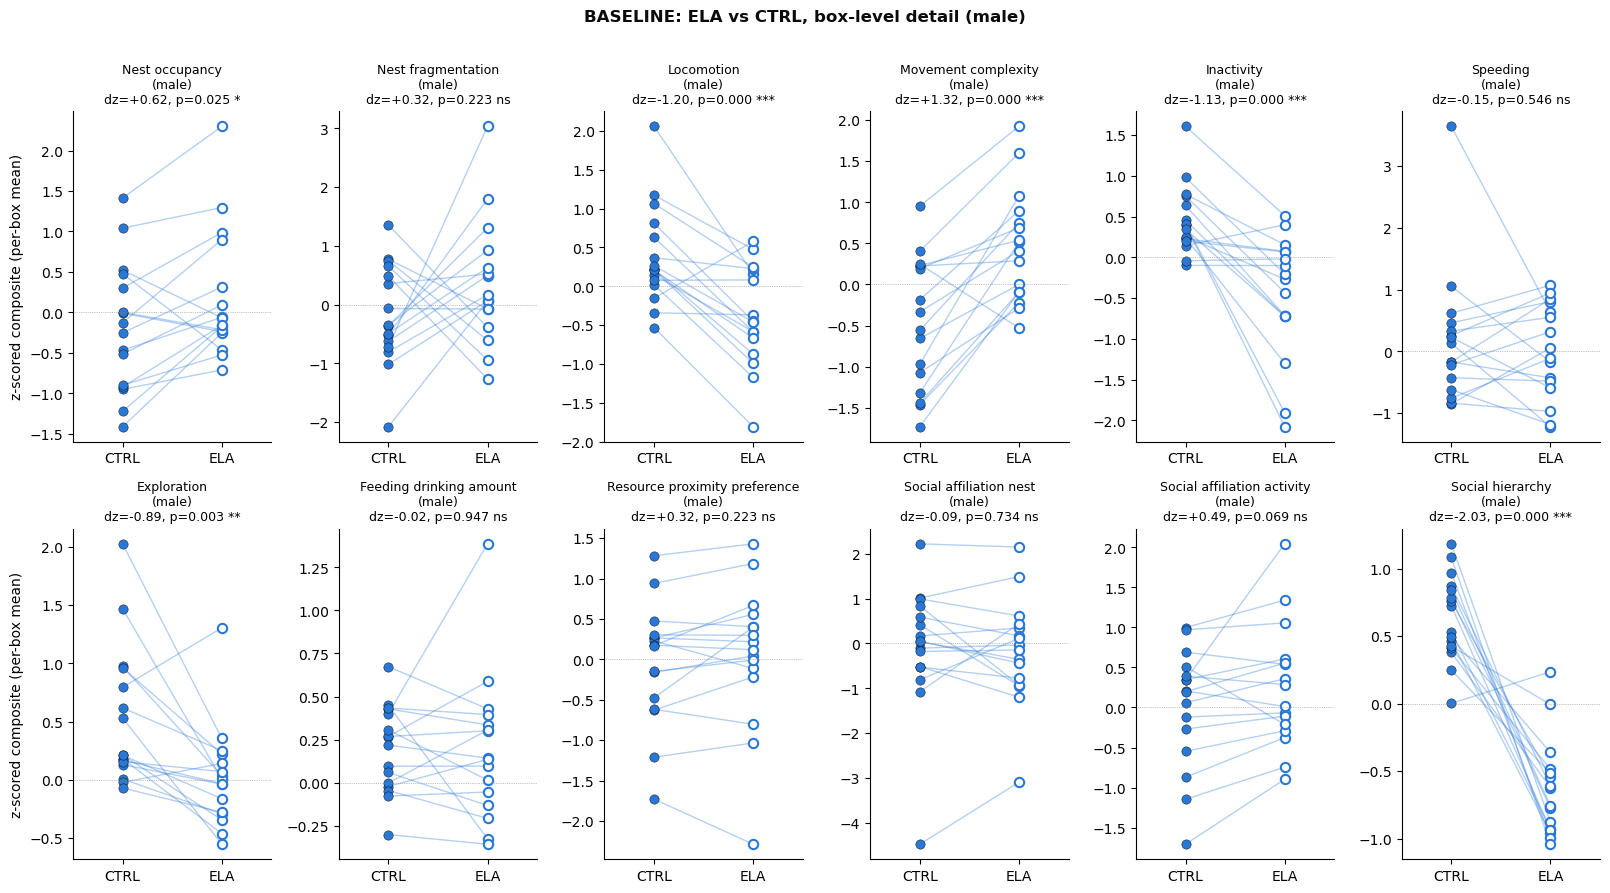

{'female': (<Figure size 1620x880 with 12 Axes>,
  array([[<Axes: title={'center': 'Nest occupancy\n(female)\ndz=+0.60, p=0.031 *'}, ylabel='z-scored composite (per-box mean)'>,
          <Axes: title={'center': 'Nest fragmentation\n(female)\ndz=-0.44, p=0.096 ns'}>,
          <Axes: title={'center': 'Locomotion\n(female)\ndz=-0.76, p=0.009 **'}>,
          <Axes: title={'center': 'Movement complexity\n(female)\ndz=+0.35, p=0.185 ns'}>,
          <Axes: title={'center': 'Inactivity\n(female)\ndz=+0.10, p=0.697 ns'}>,
          <Axes: title={'center': 'Speeding\n(female)\ndz=+0.32, p=0.224 ns'}>],
         [<Axes: title={'center': 'Exploration\n(female)\ndz=-0.27, p=0.289 ns'}, ylabel='z-scored composite (per-box mean)'>,
          <Axes: title={'center': 'Feeding drinking amount\n(female)\ndz=-0.37, p=0.158 ns'}>,
          <Axes: title={'center': 'Resource proximity preference\n(female)\ndz=+0.40, p=0.132 ns'}>,
          <Axes: title={'center': 'Social affiliation nest\n(female)\ndz=

In [20]:
# Plot and save all core domains for future reference
plot_all_domains_grid(wide, domains=CORE_DOMAIN_FEATURES,ncols=None,
                      title='BASELINE: ELA vs CTRL, box-level detail',
                      save_path=os.path.join(savepath, f'baseline_box_detail_{suffix}_core_features.png')
                      )

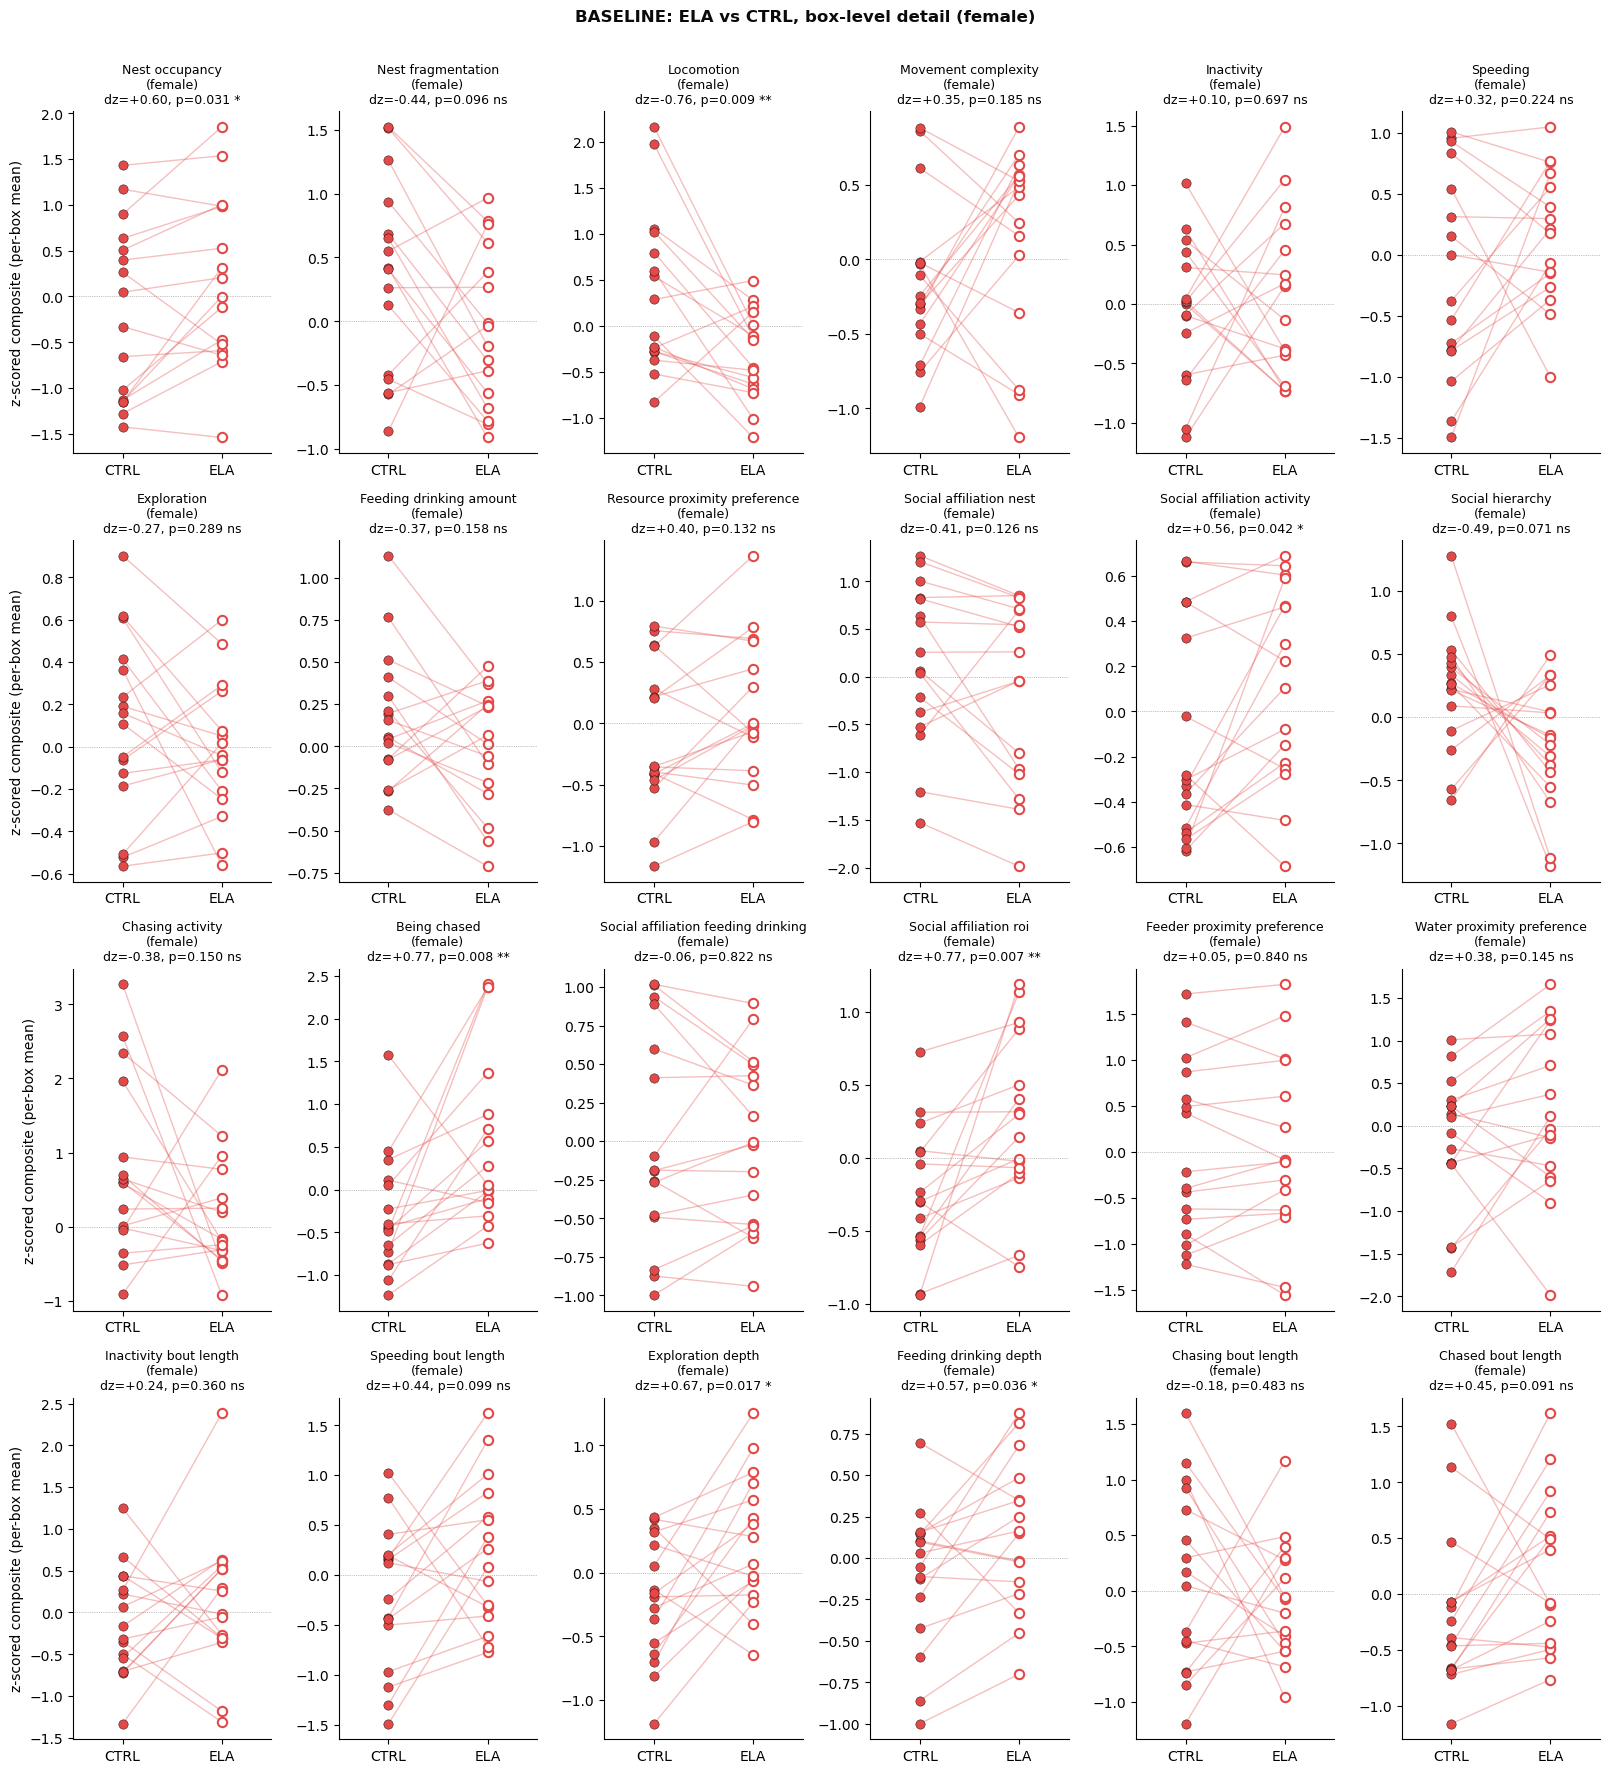

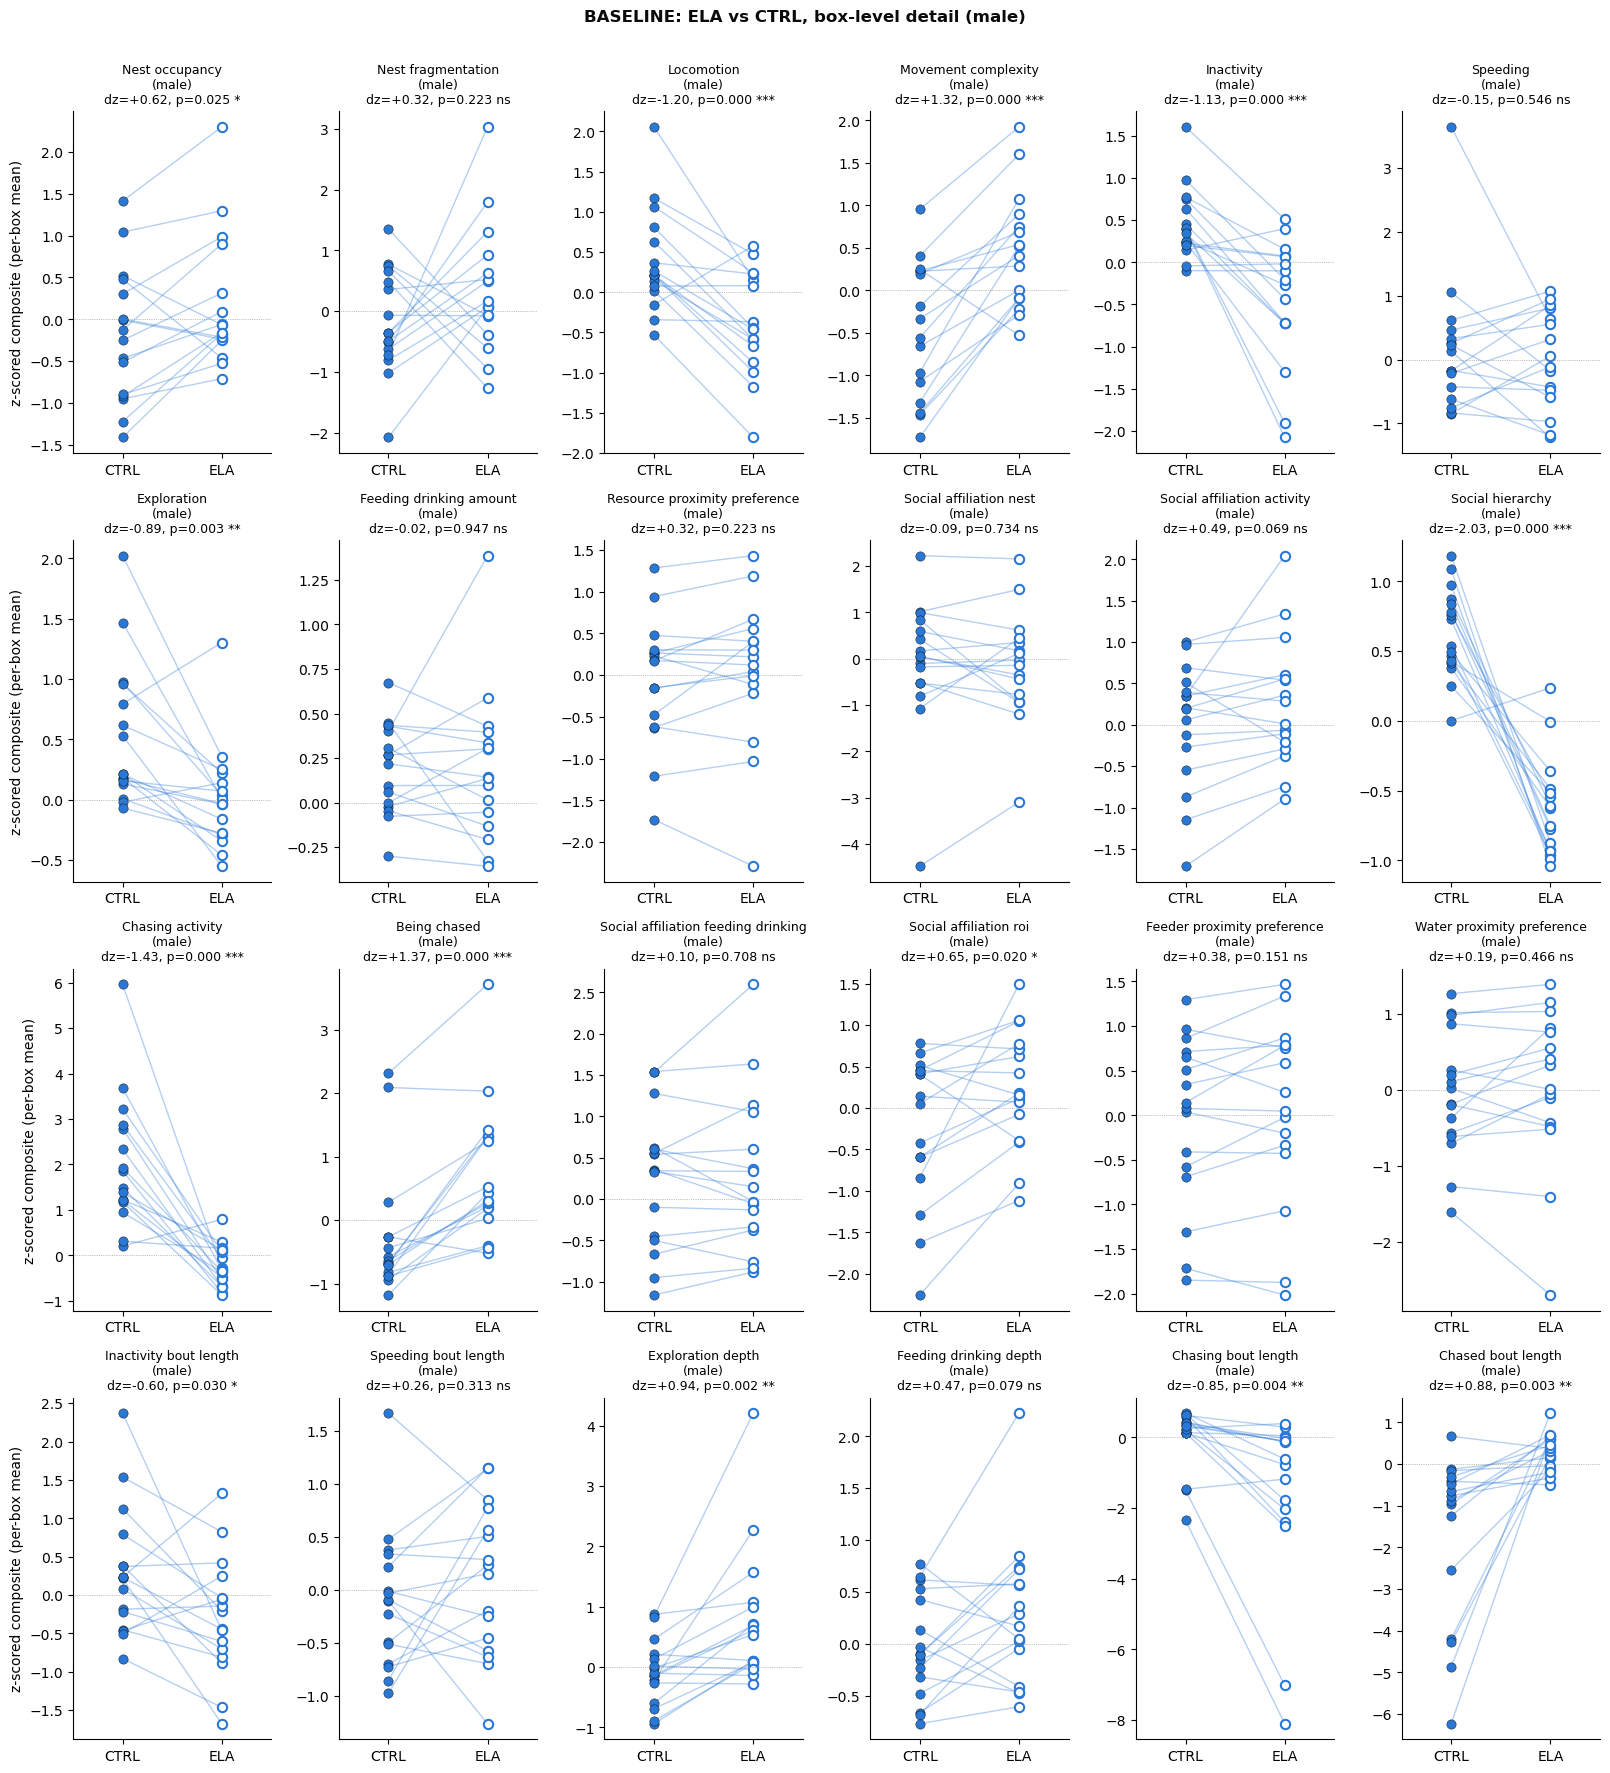

{'female': (<Figure size 1620x1760 with 24 Axes>,
  array([[<Axes: title={'center': 'Nest occupancy\n(female)\ndz=+0.60, p=0.031 *'}, ylabel='z-scored composite (per-box mean)'>,
          <Axes: title={'center': 'Nest fragmentation\n(female)\ndz=-0.44, p=0.096 ns'}>,
          <Axes: title={'center': 'Locomotion\n(female)\ndz=-0.76, p=0.009 **'}>,
          <Axes: title={'center': 'Movement complexity\n(female)\ndz=+0.35, p=0.185 ns'}>,
          <Axes: title={'center': 'Inactivity\n(female)\ndz=+0.10, p=0.697 ns'}>,
          <Axes: title={'center': 'Speeding\n(female)\ndz=+0.32, p=0.224 ns'}>],
         [<Axes: title={'center': 'Exploration\n(female)\ndz=-0.27, p=0.289 ns'}, ylabel='z-scored composite (per-box mean)'>,
          <Axes: title={'center': 'Feeding drinking amount\n(female)\ndz=-0.37, p=0.158 ns'}>,
          <Axes: title={'center': 'Resource proximity preference\n(female)\ndz=+0.40, p=0.132 ns'}>,
          <Axes: title={'center': 'Social affiliation nest\n(female)\ndz

In [21]:
# Plot and save all domains for future reference
wide_all_domain = wide = box_paired_wide(mouse_baseline, features=ALL_DOMAIN_FEATURES)
plot_all_domains_grid(wide_all_domain, domains=ALL_DOMAIN_FEATURES,ncols=None,
                      title='BASELINE: ELA vs CTRL, box-level detail',
                      save_path=os.path.join(savepath, f'baseline_box_detail_{suffix}_all_features.png')
                      )

### 4.3. Explore ELA vs CTRL differences by day (baseline day 1-3 active phase)

See `plot_domain_score_by_day.py` for function details.

Narrow the resolution to day level.

First calculate the domain scores at day level.

Same idea as step 2->3->4.0, but the output table now contains one domain-score value per mouse **per day** rather than one per mouse overall.

In [5]:
# keep 'day' in the grouping instead of collapsing it
mouse_by_day = aggregate_to_mouse(baseline_active, MOUSE_ID_COLS + ['day'], RAW_FEATURES_FOR_DOMAINS)
mouse_by_day = compute_domain_scores(mouse_by_day, domain_defs=CORE_DOMAINS)
#mouse_by_day.to_csv("/Users/xiuqi.ji/Library/CloudStorage/OneDrive-KarolinskaInstitutet/MDMA_ELA/social_box_2026/domain_score_tables/baseline_separate_days.csv",index=False)
wide_by_day = box_paired_wide(mouse_by_day, features=CORE_DOMAIN_FEATURES, extra_group_cols=('sex', 'day'))
#wide_by_day.to_csv("/Users/xiuqi.ji/Library/CloudStorage/OneDrive-KarolinskaInstitutet/MDMA_ELA/social_box_2026/domain_score_tables/baseline_paired_wide_separate_days.csv",index=False)

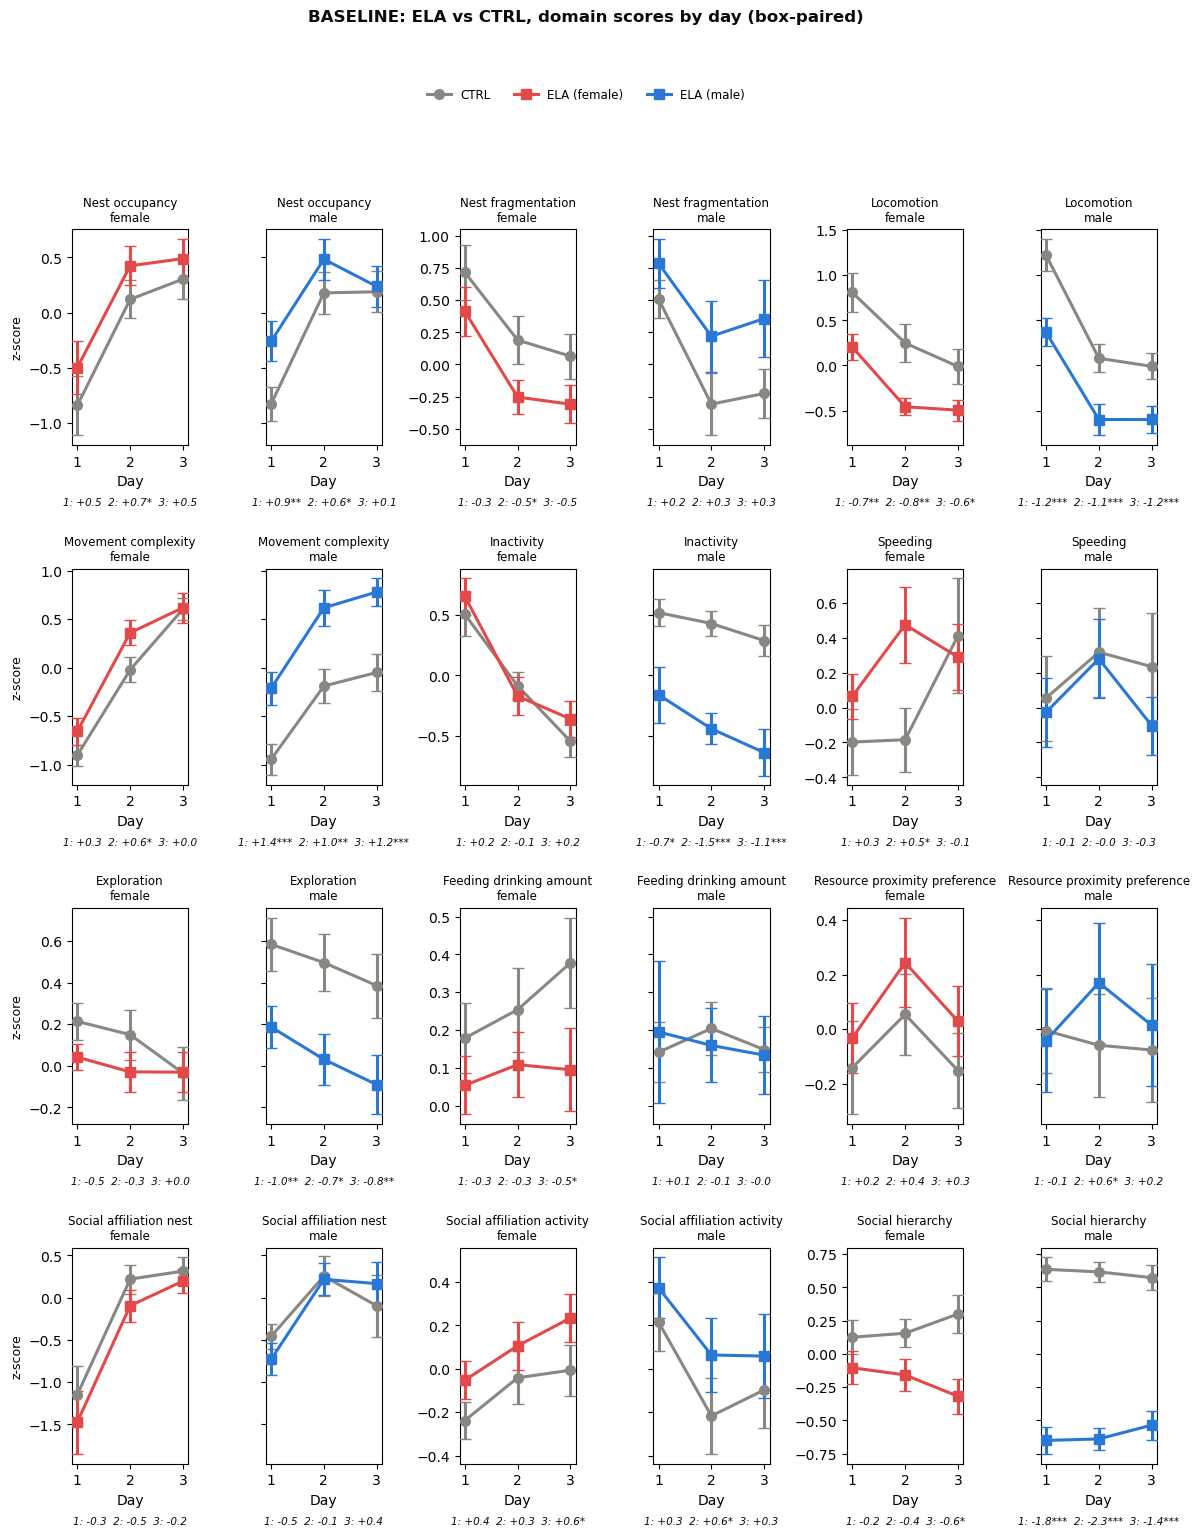

(<Figure size 1200x1560 with 24 Axes>,
 array([[<Axes: title={'center': 'Nest occupancy\nfemale'}, xlabel='Day', ylabel='z-score'>,
         <Axes: title={'center': 'Nest occupancy\nmale'}, xlabel='Day'>,
         <Axes: title={'center': 'Nest fragmentation\nfemale'}, xlabel='Day'>,
         <Axes: title={'center': 'Nest fragmentation\nmale'}, xlabel='Day'>,
         <Axes: title={'center': 'Locomotion\nfemale'}, xlabel='Day'>,
         <Axes: title={'center': 'Locomotion\nmale'}, xlabel='Day'>],
        [<Axes: title={'center': 'Movement complexity\nfemale'}, xlabel='Day', ylabel='z-score'>,
         <Axes: title={'center': 'Movement complexity\nmale'}, xlabel='Day'>,
         <Axes: title={'center': 'Inactivity\nfemale'}, xlabel='Day'>,
         <Axes: title={'center': 'Inactivity\nmale'}, xlabel='Day'>,
         <Axes: title={'center': 'Speeding\nfemale'}, xlabel='Day'>,
         <Axes: title={'center': 'Speeding\nmale'}, xlabel='Day'>],
        [<Axes: title={'center': 'Exploration

In [ ]:

# Day-on-x-axis trajectory plot (mean+/-SEM per day, box-paired, with per-day Cohen's dz
# annotations) - see plot_domain_score_by_day.py for the function signature.
from plot_domain_score_by_day import plot_domain_score_by_day, plot_domain_scores_by_day_grid

plot_domain_scores_by_day_grid(
    wide_by_day,
    CORE_DOMAIN_FEATURES,
    title='BASELINE: ELA vs CTRL, domain scores by day (box-paired)',
    max_cols=3,
    show_individual_boxes=False,
    pair_sexes=True,
    legend_loc='top',
    save_path=os.path.join(savepath, f'baseline_domain_scores_by_day_core_features.png'),
    dpi=200
)


### 4.4. Explore ELA vs CTRL differences by smaller time window (temporal dynamics)

See `temporal_dynamics.py` for function details.

Generalizes at a finer resolution (choose from 1h/2h/3h/4h/6h/12h) for any feature. 

[drop_known_bad_blocks] dropping 64 rows: male P35 day1 active MDMA session: hours 0-5 of active phase not recorded (confirmed via 1h-resolution file - rows are entirely absent, not NaN). See matched_window_recovery.py for how to recover a partial-window comparison instead of dropping outright.
[load_temporal_data] ['normDS'] not available at 4h resolution, dropped (domains using them are scored on their remaining features only)


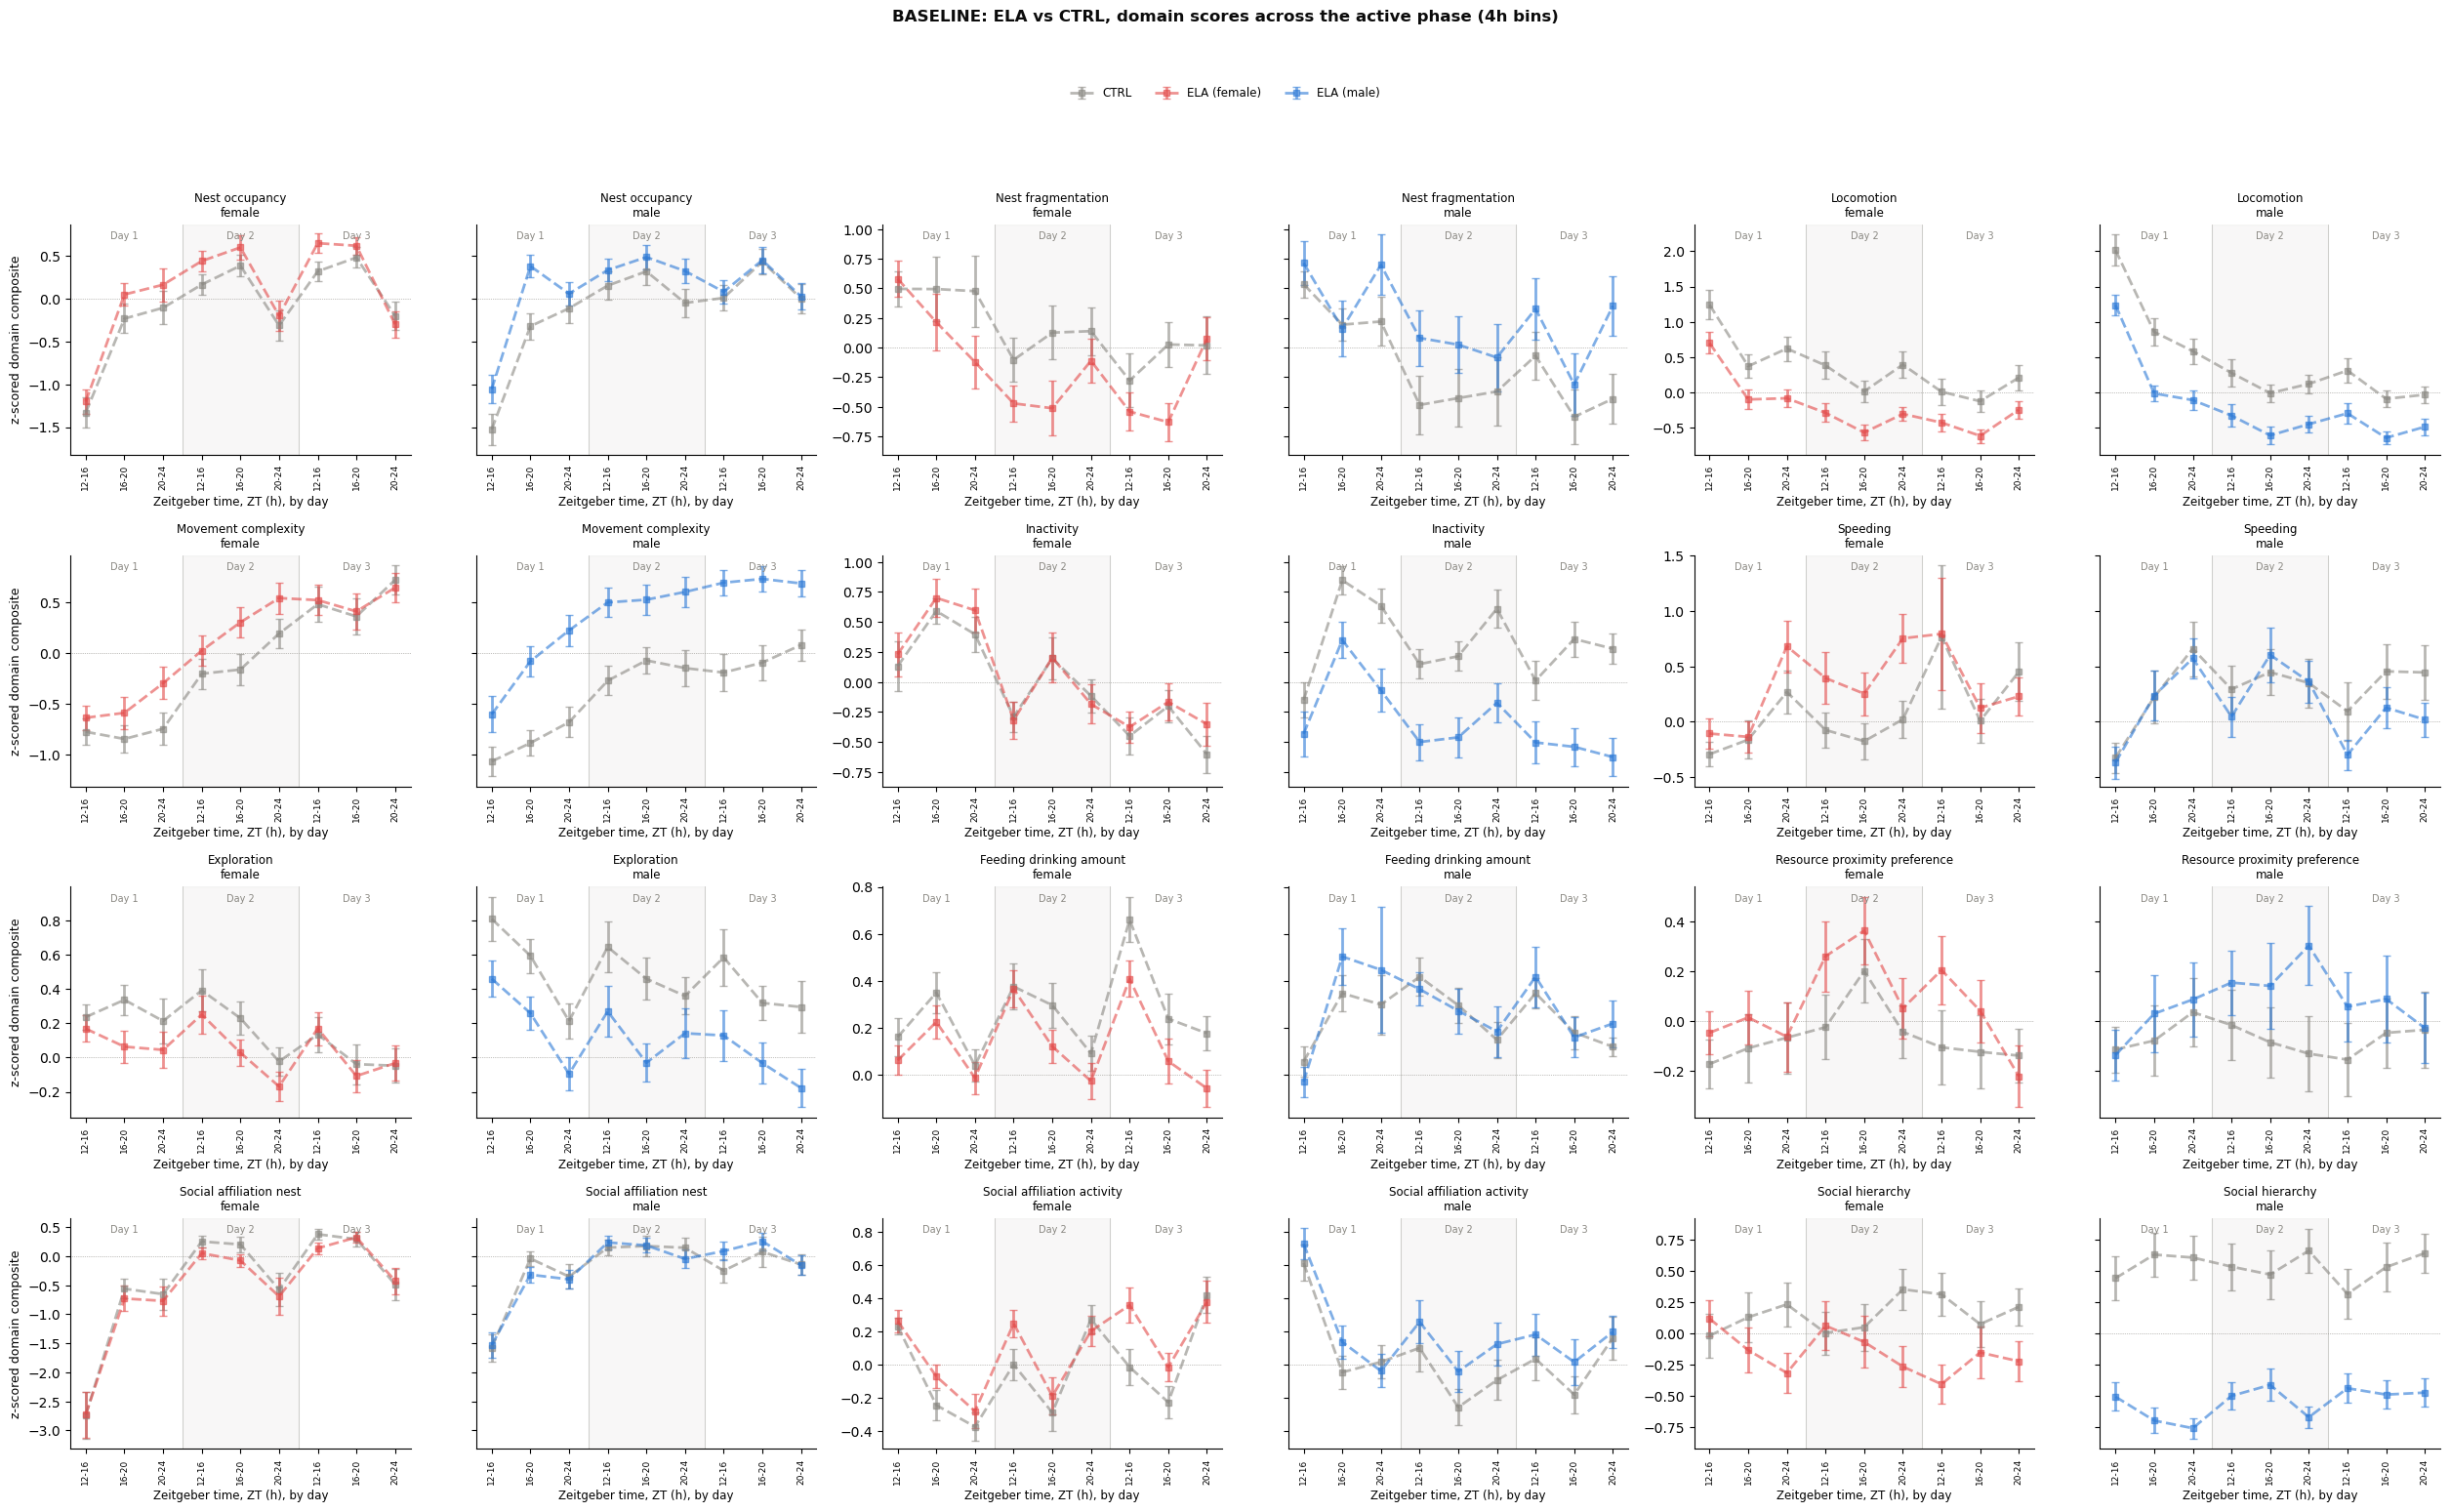

(<Figure size 2520x1560 with 24 Axes>,
 array([[<Axes: title={'center': 'Nest occupancy\nfemale'}, xlabel='Zeitgeber time, ZT (h), by day', ylabel='z-scored domain composite'>,
         <Axes: title={'center': 'Nest occupancy\nmale'}, xlabel='Zeitgeber time, ZT (h), by day'>,
         <Axes: title={'center': 'Nest fragmentation\nfemale'}, xlabel='Zeitgeber time, ZT (h), by day'>,
         <Axes: title={'center': 'Nest fragmentation\nmale'}, xlabel='Zeitgeber time, ZT (h), by day'>,
         <Axes: title={'center': 'Locomotion\nfemale'}, xlabel='Zeitgeber time, ZT (h), by day'>,
         <Axes: title={'center': 'Locomotion\nmale'}, xlabel='Zeitgeber time, ZT (h), by day'>],
        [<Axes: title={'center': 'Movement complexity\nfemale'}, xlabel='Zeitgeber time, ZT (h), by day', ylabel='z-scored domain composite'>,
         <Axes: title={'center': 'Movement complexity\nmale'}, xlabel='Zeitgeber time, ZT (h), by day'>,
         <Axes: title={'center': 'Inactivity\nfemale'}, xlabel='Zeitge

In [6]:

from temporal_dynamics import (
    load_temporal_data, plot_temporal_grid, plot_session_trajectory_grid,
)

RESOLUTION = '4h'  # swap for '1h' / '2h' / '4h' / '6h' / '12h' as desired
# set keep_day = True to plot complete trajectories, otherwise the same time window in the three days will be averaged
baseline_by_window = load_temporal_data(RESOLUTION, domain_defs=CORE_DOMAINS,
                                         time_points='baseline', data_path=DATA_PATH,
                                         keep_day=True)
# similar args as day level plots
plot_temporal_grid(
    baseline_by_window, CORE_DOMAIN_FEATURES, group='background',
    pair_sexes=True,
    max_cols=3,
    legend_loc='top',
    ylabel='z-scored domain composite',
    title=f'BASELINE: ELA vs CTRL, domain scores across the active phase ({RESOLUTION} bins)',
    save_path=os.path.join(savepath, f'baseline_temporal_{RESOLUTION}.png'),
    #save_path=None,
    dpi=300
)

### 4.5. BASELINE Inactive Phase

## 5. Post-treatment comparisons

>**in progress**

current workflow:
- calculate the post treatment-baseline deltas, separate by condition
- determine treatment x background interaction -> fit per domain per sex: delta ~ background * treatment, random = box_ID
- does MDMA bring ELA animals closer to the CTRL level


### 5.0. Compute domain scores for both baseline and post-treatment

Calculate the domain score for after treatment
- Load full data and use baseline distribution as reference 
- separate by day?

In [ ]:
# Needs both baseline AND MDMA-session rows on the SAME z-score scale, hence reference_mask.
active_all = filter_data(df, phase='active')  # both time_points, active phase only
mouse_sess = aggregate_to_mouse(active_all, MOUSE_ID_COLS + ['time_point'], RAW_FEATURES_FOR_DOMAINS)
baseline_mask = mouse_sess['time_point'] == 'baseline'
mouse_sess = compute_domain_scores(mouse_sess, domain_defs=CORE_DOMAINS, reference_mask=baseline_mask)

deltas = mouse_level_deltas(mouse_sess, features=CORE_DOMAIN_FEATURES, id_cols=MOUSE_ID_COLS,
                             session_col='time_point', session_values=('baseline', 'MDMA'))

print("\n" + "=" * 70)
print("TREATMENT: box-level MDMA vs saline delta (core domains, both sexes pooled per test)")
print("=" * 70)
for sex in ['female', 'male']:
    sub = deltas[deltas.sex == sex]
    res = box_level_delta_table(sub, CORE_DOMAIN_FEATURES)
    print(f"\n--- {sex} ---")
    print(res[['feature', 'hedges_g', 'p_ttest', 'p_fdr']].to_string(index=False))

### 5.0 Raw deltas by condition

One panel per core domain x sex, individual-mouse delta in each of the 4 background x treatment conditions (CTRL_saline, CTRL_MDMA, ELA_saline, ELA_MDMA) - before fitting anything, see `treatment_interaction.py`.

In [ ]:
from treatment_interaction import (
    plot_deltas_by_condition_grid,
    run_domain_mixedmodels, plot_bg_x_treatment_interaction, plot_mixedmodel_forest,
    compute_normalization_table, plot_normalization,
    compute_window_deltas, plot_delta_by_window_grid,
)

savepath_tx = "/Users/xiuqi.ji/Library/CloudStorage/OneDrive-KarolinskaInstitutet/MDMA_ELA/social_box_2026/plots/treatment_MDMA_vs_saline"

In [ ]:
plot_deltas_by_condition_grid(
    deltas, CORE_DOMAIN_FEATURES, sexes=('female', 'male'),
    title='TREATMENT: raw deltas by condition (core domains, before model fit)',
    save_path=os.path.join(savepath_tx, 'treatment_deltas_by_condition.png'),
)

### 5.1 Does ELA modulate the MDMA response?

Mixed model: `delta ~ background * treatment`, random intercept = box. One fit per domain per sex (see `treatment_interaction.py`).

In [ ]:
mm = run_domain_mixedmodels(deltas, CORE_DOMAIN_FEATURES, sexes=('female', 'male'))
print("\n" + "=" * 70)
print("MIXED MODEL: delta ~ background * treatment (random=box), all core domains")
print("(nominal p; p_fdr corrects across the 12 domains within each sex x term)")
print("=" * 70)
print(mm[mm.term == 'background_x_treatment'].sort_values('p')
      [['domain', 'sex', 'coef', 'p', 'p_fdr', 'n']].to_string(index=False))

# Overview: which domains show a background x treatment interaction at all (both sexes side by
# side) - look at this before drilling into individual-domain panels below.
plot_mixedmodel_forest(
    mm, term='background_x_treatment', feature_order=CORE_DOMAIN_FEATURES,
    title='Background x treatment interaction, by domain (does ELA modulate the MDMA response?)',
    save_path=os.path.join(savepath_tx, 'treatment_mixedmodel_interaction_forest.png'),
)

# Drill-down: the domains with the strongest interaction, per sex, with individual mice shown
# (faint points) so within-group response variability is visible, not just the mean.
for sex in ['female', 'male']:
    plot_bg_x_treatment_interaction(
        deltas, mm, sex=sex, n_panels=12,
        save_path=os.path.join(savepath_tx, f'treatment_bg_x_interaction_{sex}_all.png'),
    )

### 5.2 Does MDMA normalize ELA animals toward the CTRL level?

Compares the box-paired ELA-CTRL gap (Cohen's dz) at baseline vs. post-injection, separately in MDMA-dosed and saline-dosed boxes - a domain counts as "normalizing" if the gap narrows specifically in MDMA-dosed boxes, beyond whatever narrowing saline-dosed boxes show on retest alone (`normalization_index > 0`).

In [ ]:
norm_table = compute_normalization_table(mouse_sess, CORE_DOMAIN_FEATURES, sexes=('female', 'male'))
print("\n" + "=" * 70)
print("NORMALIZATION: does MDMA narrow the ELA-CTRL gap more than saline (retest) does?")
print("=" * 70)
print(norm_table[['feature', 'sex', 'dz_baseline_MDMAbox', 'dz_post_MDMAbox',
                   'shrink_MDMA', 'shrink_saline', 'normalization_index']]
      .sort_values('normalization_index', ascending=False).to_string(index=False))

for sex in ['female', 'male']:
    plot_normalization(
        norm_table, sex=sex, feature_order=CORE_DOMAIN_FEATURES,
        save_path=os.path.join(savepath_tx, f'treatment_normalization_{sex}.png'),
    )

### 5.3 Time-course of the drug effect

Small (RESOLUTION-bin, from step 6) windows vs. the whole-session (12h, "large window") number already computed above. Restricted to the domains with the clearest overall MDMA main effect, to keep the grid readable - swap in any `CORE_DOMAIN_FEATURES` subset you want to look at instead.

In [ ]:
df_fine = load_data(female_path=os.path.join(DATA_PATH, f'female_{RESOLUTION}_filtered.csv'),
                     male_path=os.path.join(DATA_PATH, f'male_{RESOLUTION}_filtered.csv'))
window_deltas = compute_window_deltas(df_fine, domain_defs=CORE_DOMAINS, id_cols=MOUSE_ID_COLS)

top_mdma_domains = (mm[mm.term == 'treatment_MDMA'].groupby('domain')['p'].min()
                     .sort_values().head(4).index.tolist())

plot_delta_by_window_grid(
    window_deltas, top_mdma_domains, full_session_deltas=deltas,
    title=f'Time-course of the MDMA effect ({RESOLUTION} bins; dashed = whole-session mean, '
          'dotted = saline-box reference)',
    save_path=os.path.join(savepath_tx, 'treatment_delta_by_window.png'),
)

### 5.3.1 Full session trajectory (absolute value, not delta)

Same time-course, but the ABSOLUTE value (z-scored composite) rather than the MDMA-vs-baseline delta above, and the FULL arc - baseline days 1-3, a visual break at the treatment boundary, then post-injection days 1-3 - in one panel per domain, split by condition (CTRL_saline/CTRL_MDMA/ELA_saline/ELA_MDMA, since both treatment arms are in play here). Companion view to 7.3 (which shows how far each group MOVED); this shows what each group's whole trajectory actually looks like, not just the post-injection session in isolation.

Loads BOTH time_points with `keep_day=True` (day kept as its own axis, not averaged) so the z-scoring reference is baseline (same scale as 7.1-7.3) AND each day's shape within each session is visible - see `temporal_dynamics.plot_session_trajectory()`. All core domains, wrapped into a grid, one figure per sex (12 domains is too wide for a single row - see `plot_session_trajectory_grid()`'s docstring).

In [ ]:
full_traj_by_window = load_temporal_data(RESOLUTION, domain_defs=CORE_DOMAINS,
                                          time_points=['baseline', 'MDMA'], data_path=DATA_PATH,
                                          keep_day=True)

for sex in ['female', 'male']:
    plot_session_trajectory_grid(
        full_traj_by_window, CORE_DOMAIN_FEATURES, sex=sex, group='condition', ncols=3,
        title=f'{sex}: BASELINE -> POST-INJECTION domain-score trajectory by condition '
              f'({RESOLUTION} bins)',
        save_path=os.path.join(savepath_tx, f'treatment_session_trajectory_{sex}_{RESOLUTION}.png'),
    )

### 5.4 Post-injection box-level detail

The same box-by-box view as step 4.1, but for the post-injection session, with MDMA-dosed vs. saline-dosed boxes colored separately within each panel (instead of pooling treatment like the baseline plot does) - the individual-box view underneath the interaction plots in 7.1.

In [ ]:
mdma_session = mouse_sess[mouse_sess.time_point == 'MDMA']
wide_post = box_paired_wide(mdma_session, features=CORE_DOMAIN_FEATURES,
                             extra_group_cols=('sex', 'treatment'))

post_panels = [(f, sex) for sex in ['male', 'female']
               for f in mm[(mm.sex == sex) & (mm.term == 'background_x_treatment')]
               .sort_values('p')['domain'].head(3)]
custom_panels = [
    ('social_hierarchy_score', 'male'),
    ('social_hierarchy_score', 'female'),
    ('locomotion_score', 'male'),
    ('locomotion_score', 'female'),
    ('exploration_score', 'male'),
    ('exploration_score', 'female'),
]

plot_domains_by_box_grid(
    wide_post, custom_panels, group_col='treatment',
    title='POST-INJECTION: ELA vs CTRL, box-level detail, split by treatment',
    save_path=os.path.join(savepath_tx, 'treatment_post_injection_box_detail_1.png'),
)

### 5.5 Post-injection box-level detail (delta)

Same box-level detail, but on the delta (post-injection - baseline) rather than the raw post-injection score - i.e. `box_paired_wide()` applied to `deltas` (step 7's mouse-level delta table) instead of to `mouse_sess`. Same domains/panels as 7.4 for a direct side-by-side: 7.4 shows where each box ends UP, 7.5 shows how far each box MOVED.

In [ ]:
delta_features = [f'{f}__delta' for f in CORE_DOMAIN_FEATURES]
wide_delta = box_paired_wide(deltas, features=delta_features, extra_group_cols=('sex', 'treatment'))

# post_panels are plain domain names (e.g. 'speeding_score') - value_suffix='__delta' below
# appends '__delta' to build the actual column lookup ('speeding_score__delta_ELA', etc.),
# same domains/panel selection as 7.4.
plot_domains_by_box_grid(
    wide_delta, post_panels, group_col='treatment', value_suffix='__delta',
    ylabel='Δ (post-injection − baseline)\nz-scored composite',
    title='POST-INJECTION: ELA vs CTRL, box-level Δ detail, split by treatment',
    save_path=os.path.join(savepath_tx, 'treatment_delta_box_detail.png'),
)

## . Add more here

Ideas already discussed that aren't wired up as reusable functions yet - feel free to build these
out using the building blocks above:

- age-split analysis: `filter_data(..., age='P35')` vs `age='P42'`, then repeat steps 2-4
- individual stratification / clustering (dominance x social quadrants, k-means on the full
  domain-score vector) - see chat history for example code, not yet in `lib/`
- matched-window recovery for the male P35 day-1 gap (see `matched_window_recovery.py`)
- `treatment_interaction.py`'s `compute_window_deltas()` generalizes to 1h/2h/4h/6h files too -
  useful if 3h bins turn out too coarse (or too noisy) for a domain of interest